# ALMA Archive Connection

This notebook explores programmatic access to the ALMA Science Archive.

## Initial objectives

1. Verify the Python and Jupyter environment.
2. Connect to the ALMA Science Archive.
3. Run a minimal archive query.
4. Inspect the returned columns and units.
5. Identify fields required for duplication checking.

In [1]:
import sys
from pathlib import Path

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nCurrent working directory:")
print(Path.cwd())

Python executable:
/Users/nana/opt/anaconda3/envs/alma-duplication/bin/python

Python version:
3.12.11 | packaged by Anaconda, Inc. | (main, Jun  5 2025, 08:06:15) [Clang 14.0.6 ]

Current working directory:
/Users/nana/Documents/alma-duplication-tool/notebooks


In [2]:
import astropy
import astroquery
import pyvo
import pandas as pd
import matplotlib

print("Astropy:", astropy.__version__)
print("Astroquery:", astroquery.__version__)
print("PyVO:", pyvo.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

print("\nNotebook environment is ready.")

Astropy: 8.0.1
Astroquery: 0.4.11
PyVO: 1.9.1
Pandas: 3.0.5
Matplotlib: 3.11.1

Notebook environment is ready.


In [3]:
from astropy.coordinates import SkyCoord
import astropy.units as u

test_coordinate = SkyCoord(
    ra="12h34m56.7s",
    dec="-12d34m56s",
    frame="icrs",
)

print("RA in degrees:", test_coordinate.ra.deg)
print("Dec in degrees:", test_coordinate.dec.deg)
print("Coordinate:", test_coordinate)

RA in degrees: 188.73624999999998
Dec in degrees: -12.582222222222223
Coordinate: <SkyCoord (ICRS): (ra, dec) in deg
    (188.73625, -12.58222222)>


## Environment check

- Python environment: `alma-duplication`
- Python version: 3.12.11
- Archive access package: PyVO
- Coordinate handling package: Astropy
- Table-processing package: Pandas
- Status: Development environment successfully configured

## Next task

Connect to the ALMA Science Archive TAP service and run a minimal query.

In [1]:
import alma_duplicate

print("Package location:")
print(alma_duplicate.__file__)

print("\nLocal project package imported successfully.")

Package location:
/Users/nana/Documents/alma-duplication-tool/src/alma_duplicate/__init__.py

Local project package imported successfully.


## ALMA TAP service connection

The European ALMA Science Archive provides a Table Access Protocol
(TAP) service. Queries are written in the Astronomical Data Query
Language (ADQL) and executed using PyVO.

This section:

1. Creates a connection to the European ALMA TAP service.
2. Executes a small query with a maximum of five rows.
3. Inspects the returned columns and data types.

In [2]:
import pandas as pd
import pyvo

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

TAP_URL = "https://almascience.eso.org/tap"

print("PyVO version:", pyvo.__version__)
print("TAP endpoint:", TAP_URL)

PyVO version: 1.9.1
TAP endpoint: https://almascience.eso.org/tap


In [3]:
service = pyvo.dal.TAPService(TAP_URL)

print("TAP service object created successfully.")
print(service)

TAP service object created successfully.
TAPService(baseurl : 'https://almascience.eso.org/tap', description : 'None')


### Minimal archive query

The first query requests only five rows and a limited number of columns.
This verifies the connection without downloading a large result table.

In [4]:
minimal_query = """
SELECT TOP 5
    proposal_id,
    target_name,
    s_ra,
    s_dec,
    frequency,
    bandwidth,
    spatial_resolution,
    sensitivity_10kms,
    cont_sensitivity_bandwidth,
    member_ous_uid,
    is_mosaic
FROM ivoa.obscore
WHERE science_observation = 'T'
"""

print(minimal_query)


SELECT TOP 5
    proposal_id,
    target_name,
    s_ra,
    s_dec,
    frequency,
    bandwidth,
    spatial_resolution,
    sensitivity_10kms,
    cont_sensitivity_bandwidth,
    member_ous_uid,
    is_mosaic
FROM ivoa.obscore
WHERE science_observation = 'T'



In [5]:
response = service.search(minimal_query)

print("Query completed successfully.")
print("Response type:", type(response))

Query completed successfully.
Response type: <class 'pyvo.dal.tap.TAPResults'>


In [6]:
archive_table = response.to_table()

print("Astropy table created.")
print("Number of rows:", len(archive_table))
print("Number of columns:", len(archive_table.colnames))
print("Columns:")
print(archive_table.colnames)

Astropy table created.
Number of rows: 5
Number of columns: 11
Columns:
['proposal_id', 'target_name', 's_ra', 's_dec', 'frequency', 'bandwidth', 'spatial_resolution', 'sensitivity_10kms', 'cont_sensitivity_bandwidth', 'member_ous_uid', 'is_mosaic']


In [7]:
archive_df = archive_table.to_pandas()

print("DataFrame shape:", archive_df.shape)
display(archive_df)

DataFrame shape: (5, 11)


,proposal_id,target_name,s_ra,s_dec,frequency,bandwidth,spatial_resolution,sensitivity_10kms,cont_sensitivity_bandwidth,member_ous_uid,is_mosaic
0,2021.1.00869.L,ad3a-22078,240.052125,-54.425472,87.492595,9.375000e+08,1.159672,3.811278,0.105020,uid://A001/X1590/X18e0,F
1,2021.1.00869.L,ad3a-22078,240.052125,-54.425472,84.566616,9.375000e+08,1.159672,3.783308,0.105020,uid://A001/X1590/X18e0,F
2,2021.1.00869.L,ad3a-22078,240.052125,-54.425472,85.398372,9.375000e+08,1.159672,3.765423,0.105020,uid://A001/X1590/X18e0,F
3,2021.1.00869.L,ad3a-22078,240.052125,-54.425472,86.545116,9.375000e+08,1.159672,3.831390,0.105020,uid://A001/X1590/X18e0,F
4,2024.1.01553.S,3C078,47.109262,4.110915,225.732519,2.000000e+09,0.509148,0.786219,0.026225,uid://A001/X3788/Xb661,F


In [8]:
print("Column data types:")
display(archive_df.dtypes.to_frame(name="dtype"))

print("\nMissing values:")
display(archive_df.isna().sum().to_frame(name="missing_count"))

Column data types:


,dtype
proposal_id,str
target_name,str
s_ra,float64
s_dec,float64
frequency,float64
bandwidth,float64
spatial_resolution,float64
sensitivity_10kms,float64
cont_sensitivity_bandwidth,float64
member_ous_uid,str



Missing values:


,missing_count
proposal_id,0
target_name,0
s_ra,0
s_dec,0
frequency,0
bandwidth,0
spatial_resolution,0
sensitivity_10kms,0
cont_sensitivity_bandwidth,0
member_ous_uid,0


In [9]:
column_metadata = []

for column_name in archive_table.colnames:
    column = archive_table[column_name]

    column_metadata.append(
        {
            "column": column_name,
            "unit": str(column.unit) if column.unit is not None else None,
            "dtype": str(column.dtype),
        }
    )

metadata_df = pd.DataFrame(column_metadata)

display(metadata_df)

,column,unit,dtype
0,proposal_id,NaN,<U64
1,target_name,NaN,<U256
2,s_ra,deg,float64
3,s_dec,deg,float64
4,frequency,GHz,float64
5,bandwidth,Hz,float64
6,spatial_resolution,arcsec,float64
7,sensitivity_10kms,mJy / beam,float64
8,cont_sensitivity_bandwidth,mJy / beam,float64
9,member_ous_uid,NaN,<U64


## Coordinate-based Archive query

This section queries Archive records whose spatial footprints intersect
a circular search region.

The initial example follows the official ALMA single-source query notebook
and searches around the position of Centaurus A.

The query includes additional identifiers to investigate how Archive rows,
spectral windows, datasets, and Member OUS records are related.

In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u

search_coordinate = SkyCoord(
    ra=201.365 * u.deg,
    dec=-43.019 * u.deg,
    frame="icrs",
)

search_radius = 21.6 * u.arcsec

ra_deg = search_coordinate.ra.deg
dec_deg = search_coordinate.dec.deg
radius_deg = search_radius.to(u.deg).value

print("Search RA:", ra_deg, "deg")
print("Search Dec:", dec_deg, "deg")
print("Search radius:", search_radius)
print("Search radius:", radius_deg, "deg")

Search RA: 201.365 deg
Search Dec: -43.019 deg
Search radius: 21.6 arcsec
Search radius: 0.006 deg


In [11]:
coordinate_query = f"""
SELECT TOP 100
    proposal_id,
    group_ous_uid,
    member_ous_uid,
    obs_id,
    asdm_uid,
    target_name,
    s_ra,
    s_dec,
    s_region,
    frequency,
    bandwidth,
    frequency_support,
    spatial_resolution,
    sensitivity_10kms,
    cont_sensitivity_bandwidth,
    antenna_arrays,
    is_mosaic
FROM ivoa.obscore
WHERE science_observation = 'T'
AND INTERSECTS(
    CIRCLE('ICRS', {ra_deg}, {dec_deg}, {radius_deg}),
    s_region
) = 1
"""

print(coordinate_query)


SELECT TOP 100
    proposal_id,
    group_ous_uid,
    member_ous_uid,
    obs_id,
    asdm_uid,
    target_name,
    s_ra,
    s_dec,
    s_region,
    frequency,
    bandwidth,
    frequency_support,
    spatial_resolution,
    sensitivity_10kms,
    cont_sensitivity_bandwidth,
    antenna_arrays,
    is_mosaic
FROM ivoa.obscore
WHERE science_observation = 'T'
AND INTERSECTS(
    CIRCLE('ICRS', 201.365, -43.019, 0.006),
    s_region
) = 1



In [12]:
coordinate_response = service.search(coordinate_query)
coordinate_table = coordinate_response.to_table()
coordinate_df = coordinate_table.to_pandas()

print("Coordinate query completed successfully.")
print("Number of rows:", len(coordinate_df))
print("Number of columns:", len(coordinate_df.columns))

Coordinate query completed successfully.
Number of rows: 100
Number of columns: 17


In [13]:
display_columns = [
    "proposal_id",
    "member_ous_uid",
    "obs_id",
    "target_name",
    "s_ra",
    "s_dec",
    "frequency",
    "bandwidth",
    "spatial_resolution",
    "is_mosaic",
]

display(coordinate_df[display_columns].head(20))

,proposal_id,member_ous_uid,obs_id,target_name,s_ra,s_dec,frequency,bandwidth,spatial_resolution,is_mosaic
0,2012.1.00225.S,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.19,Centaurus_a,201.365069,-43.018989,707.588542,1.875000e+09,0.174587,T
1,2012.1.00225.S,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.17,Centaurus_a,201.365069,-43.018989,690.215941,1.875000e+09,0.174587,T
2,2012.1.00225.S,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.23,Centaurus_a,201.365069,-43.018989,703.921586,1.875000e+09,0.174587,T
3,2012.1.00225.S,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.21,Centaurus_a,201.365069,-43.018989,692.039544,1.875000e+09,0.174587,T
4,2011.0.00010.S,uid://A002/X327408/X213,uid://A002/X327408/X213.source.CenA.spw.23,CenA,201.365063,-43.019112,87.767100,2.343750e+08,1.495708,F
5,2011.0.00010.S,uid://A002/X327408/X213,uid://A002/X327408/X213.source.CenA.spw.17,CenA,201.365063,-43.019112,89.028119,2.343750e+08,1.495708,F
6,2011.0.00010.S,uid://A002/X327408/X213,uid://A002/X327408/X213.source.CenA.spw.19,CenA,201.365063,-43.019112,88.472196,2.343750e+08,1.495708,F
7,2011.0.00010.S,uid://A002/X327408/X213,uid://A002/X327408/X213.source.CenA.spw.21,CenA,201.365063,-43.019112,87.171528,2.343750e+08,1.495708,F
8,2022.1.00506.S,uid://A001/X2d20/X26a4,uid://A001/X2d20/X26a4.source.Centaurus_A.spw.11,Centaurus_A,201.365017,-43.019304,151.988515,2.000000e+09,0.146130,F
9,2022.1.00506.S,uid://A001/X2d20/X26a4,uid://A001/X2d20/X26a4.source.Centaurus_A.spw.9,Centaurus_A,201.365017,-43.019304,150.030392,2.000000e+09,0.146130,F


In [14]:
identifier_summary = pd.DataFrame(
    {
        "field": [
            "proposal_id",
            "group_ous_uid",
            "member_ous_uid",
            "obs_id",
            "asdm_uid",
            "target_name",
        ],
        "unique_values": [
            coordinate_df["proposal_id"].nunique(dropna=True),
            coordinate_df["group_ous_uid"].nunique(dropna=True),
            coordinate_df["member_ous_uid"].nunique(dropna=True),
            coordinate_df["obs_id"].nunique(dropna=True),
            coordinate_df["asdm_uid"].nunique(dropna=True),
            coordinate_df["target_name"].nunique(dropna=True),
        ],
    }
)

display(identifier_summary)

,field,unique_values
0,proposal_id,11
1,group_ous_uid,17
2,member_ous_uid,25
3,obs_id,100
4,asdm_uid,25
5,target_name,5


In [15]:
member_ous_summary = (
    coordinate_df
    .groupby(
        ["proposal_id", "member_ous_uid", "target_name"],
        dropna=False,
    )
    .agg(
        row_count=("frequency", "size"),
        unique_frequencies=("frequency", "nunique"),
        min_frequency_ghz=("frequency", "min"),
        max_frequency_ghz=("frequency", "max"),
        unique_obs_ids=("obs_id", "nunique"),
        unique_asdm_uids=("asdm_uid", "nunique"),
    )
    .reset_index()
    .sort_values(
        ["row_count", "unique_frequencies"],
        ascending=False,
    )
)

display(member_ous_summary.head(20))

,proposal_id,member_ous_uid,target_name,row_count,unique_frequencies,min_frequency_ghz,max_frequency_ghz,unique_obs_ids,unique_asdm_uids
0,2011.0.00008.SV,uid://A002/X259150/X157,Centaurus A,4,4,230.137724,246.385449,4,1
1,2011.0.00010.S,uid://A002/X327408/X20f,CenA,4,4,86.075216,99.236139,4,1
2,2011.0.00010.S,uid://A002/X327408/X211,CenA,4,4,109.592329,113.242400,4,1
3,2011.0.00010.S,uid://A002/X327408/X213,CenA,4,4,87.171528,89.028119,4,1
4,2011.0.00010.S,uid://A002/X327408/X215,CenA,4,4,90.500536,93.005842,4,1
5,2011.0.00010.S,uid://A002/X327408/X217,CenA,4,4,218.060550,219.990105,4,1
6,2012.1.00225.S,uid://A002/X7d1738/Xf8,Centaurus_a,4,4,690.215941,707.588542,4,1
7,2016.1.01198.V,uid://A001/X11a7/X14,Centaurus_A,4,4,213.096375,229.096103,4,1
8,2017.1.01162.S,uid://A001/X1284/X76,Centaurus_a,4,4,343.753036,356.085324,4,1
9,2017.1.01162.S,uid://A001/X12a3/Xb0,Centaurus_a,4,4,343.752909,356.085424,4,1


In [16]:
print("Mosaic values:")
display(
    coordinate_df["is_mosaic"]
    .value_counts(dropna=False)
    .to_frame(name="row_count")
)

print("\nMissing values:")
display(
    coordinate_df
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)

Mosaic values:


,row_count
is_mosaic,
F,84
T,16



Missing values:


,missing_count
proposal_id,0
frequency,0
antenna_arrays,0
cont_sensitivity_bandwidth,0
sensitivity_10kms,0
spatial_resolution,0
frequency_support,0
bandwidth,0
s_region,0
group_ous_uid,0


In [17]:
coordinate_display_df = coordinate_df.copy()

coordinate_display_df["bandwidth_ghz"] = (
    coordinate_display_df["bandwidth"] / 1e9
)

display(
    coordinate_display_df[
        [
            "proposal_id",
            "member_ous_uid",
            "target_name",
            "frequency",
            "bandwidth",
            "bandwidth_ghz",
        ]
    ].head(20)
)

,proposal_id,member_ous_uid,target_name,frequency,bandwidth,bandwidth_ghz
0,2012.1.00225.S,uid://A002/X7d1738/Xf8,Centaurus_a,707.588542,1.875000e+09,1.875000
1,2012.1.00225.S,uid://A002/X7d1738/Xf8,Centaurus_a,690.215941,1.875000e+09,1.875000
2,2012.1.00225.S,uid://A002/X7d1738/Xf8,Centaurus_a,703.921586,1.875000e+09,1.875000
3,2012.1.00225.S,uid://A002/X7d1738/Xf8,Centaurus_a,692.039544,1.875000e+09,1.875000
4,2011.0.00010.S,uid://A002/X327408/X213,CenA,87.767100,2.343750e+08,0.234375
5,2011.0.00010.S,uid://A002/X327408/X213,CenA,89.028119,2.343750e+08,0.234375
6,2011.0.00010.S,uid://A002/X327408/X213,CenA,88.472196,2.343750e+08,0.234375
7,2011.0.00010.S,uid://A002/X327408/X213,CenA,87.171528,2.343750e+08,0.234375
8,2022.1.00506.S,uid://A001/X2d20/X26a4,Centaurus_A,151.988515,2.000000e+09,2.000000
9,2022.1.00506.S,uid://A001/X2d20/X26a4,Centaurus_A,150.030392,2.000000e+09,2.000000


### Count all matching Archive rows

The exploratory query returned exactly 100 rows and may therefore have
reached the `TOP 100` limit. Before downloading the complete result set,
a count query is used to determine the total number of matching Archive rows.

In [18]:
coordinate_count_query = f"""
SELECT COUNT(*) AS total_rows
FROM ivoa.obscore
WHERE science_observation = 'T'
AND INTERSECTS(
    CIRCLE('ICRS', {ra_deg}, {dec_deg}, {radius_deg}),
    s_region
) = 1
"""

print(coordinate_count_query)


SELECT COUNT(*) AS total_rows
FROM ivoa.obscore
WHERE science_observation = 'T'
AND INTERSECTS(
    CIRCLE('ICRS', 201.365, -43.019, 0.006),
    s_region
) = 1



In [19]:
count_response = service.search(coordinate_count_query)
count_table = count_response.to_table()
count_df = count_table.to_pandas()

display(count_df)

,total_rows
0,434


In [20]:
total_matching_rows = int(count_df.iloc[0, 0])

print("Total matching Archive rows:", total_matching_rows)
print("Rows retrieved in exploratory query:", len(coordinate_df))
print(
    "Exploratory result was truncated:",
    total_matching_rows > len(coordinate_df),
)

Total matching Archive rows: 434
Rows retrieved in exploratory query: 100
Exploratory result was truncated: True


In [21]:
mosaic_summary = (
    coordinate_df
    .groupby("is_mosaic", dropna=False)
    .agg(
        archive_row_count=("obs_id", "size"),
        proposal_count=("proposal_id", "nunique"),
        member_ous_count=("member_ous_uid", "nunique"),
        asdm_count=("asdm_uid", "nunique"),
    )
    .reset_index()
)

display(mosaic_summary)

,is_mosaic,archive_row_count,proposal_count,member_ous_count,asdm_count
0,F,84,9,21,21
1,T,16,4,4,4


In [22]:
example_member_ous = coordinate_df["member_ous_uid"].iloc[0]

print("Example Member OUS:")
print(example_member_ous)

Example Member OUS:
uid://A002/X7d1738/Xf8


In [23]:
example_spectral_setup = (
    coordinate_df.loc[
        coordinate_df["member_ous_uid"] == example_member_ous,
        [
            "obs_id",
            "frequency",
            "bandwidth",
            "frequency_support",
            "sensitivity_10kms",
            "cont_sensitivity_bandwidth",
        ],
    ]
    .sort_values("frequency")
)

display(example_spectral_setup)

,obs_id,frequency,bandwidth,frequency_support,sensitivity_10kms,cont_sensitivity_bandwidth
1,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.17,690.215941,1.875000e+09,"[689.28..691.15GHz,976.56kHz,10.8mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [691.10..692.98GHz...",10.803344,0.593166
3,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.21,692.039544,1.875000e+09,"[689.28..691.15GHz,976.56kHz,10.8mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [691.10..692.98GHz...",10.819007,0.593166
2,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.23,703.921586,1.875000e+09,"[689.28..691.15GHz,976.56kHz,10.8mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [691.10..692.98GHz...",10.463668,0.593166
0,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.19,707.588542,1.875000e+09,"[689.28..691.15GHz,976.56kHz,10.8mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [691.10..692.98GHz...",10.496009,0.593166


## Retrieve the complete coordinate-query result

The exploratory query used `TOP 100` and returned only part of the result.
This section retrieves all matching Archive rows and verifies the result
against the previous `COUNT(*)` query.

In [24]:
full_coordinate_query = coordinate_query.replace(
    "SELECT TOP 100",
    "SELECT",
    1,
)

print(full_coordinate_query)


SELECT
    proposal_id,
    group_ous_uid,
    member_ous_uid,
    obs_id,
    asdm_uid,
    target_name,
    s_ra,
    s_dec,
    s_region,
    frequency,
    bandwidth,
    frequency_support,
    spatial_resolution,
    sensitivity_10kms,
    cont_sensitivity_bandwidth,
    antenna_arrays,
    is_mosaic
FROM ivoa.obscore
WHERE science_observation = 'T'
AND INTERSECTS(
    CIRCLE('ICRS', 201.365, -43.019, 0.006),
    s_region
) = 1



In [25]:
full_response = service.search(
    full_coordinate_query,
    maxrec=total_matching_rows,
)

full_table = full_response.to_table()
full_coordinate_df = full_table.to_pandas()

print("Expected rows:", total_matching_rows)
print("Retrieved rows:", len(full_coordinate_df))
print("Number of columns:", len(full_coordinate_df.columns))

Expected rows: 434
Retrieved rows: 434
Number of columns: 17


In [26]:
assert len(full_coordinate_df) == total_matching_rows, (
    f"Expected {total_matching_rows} rows, "
    f"but retrieved {len(full_coordinate_df)} rows."
)

print("Complete coordinate result retrieved successfully.")

Complete coordinate result retrieved successfully.


In [27]:
full_identifier_summary = pd.DataFrame(
    {
        "field": [
            "proposal_id",
            "group_ous_uid",
            "member_ous_uid",
            "obs_id",
            "asdm_uid",
            "target_name",
        ],
        "unique_values": [
            full_coordinate_df["proposal_id"].nunique(dropna=True),
            full_coordinate_df["group_ous_uid"].nunique(dropna=True),
            full_coordinate_df["member_ous_uid"].nunique(dropna=True),
            full_coordinate_df["obs_id"].nunique(dropna=True),
            full_coordinate_df["asdm_uid"].nunique(dropna=True),
            full_coordinate_df["target_name"].nunique(dropna=True),
        ],
    }
)

display(full_identifier_summary)

,field,unique_values
0,proposal_id,24
1,group_ous_uid,82
2,member_ous_uid,108
3,obs_id,434
4,asdm_uid,108
5,target_name,8


In [28]:
full_mosaic_summary = (
    full_coordinate_df
    .groupby("is_mosaic", dropna=False)
    .agg(
        archive_row_count=("obs_id", "size"),
        proposal_count=("proposal_id", "nunique"),
        member_ous_count=("member_ous_uid", "nunique"),
        asdm_count=("asdm_uid", "nunique"),
    )
    .reset_index()
)

display(full_mosaic_summary)

,is_mosaic,archive_row_count,proposal_count,member_ous_count,asdm_count
0,F,324,22,79,79
1,T,110,12,29,29


In [29]:
example_frequency_support = (
    full_coordinate_df.loc[
        full_coordinate_df["member_ous_uid"] == example_member_ous,
        "frequency_support",
    ]
    .dropna()
    .unique()
)

print("Number of unique frequency_support values:")
print(len(example_frequency_support))

print("\nComplete frequency_support value:")
print(example_frequency_support[0])

Number of unique frequency_support values:
1

Complete frequency_support value:
[689.28..691.15GHz,976.56kHz,10.8mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [691.10..692.98GHz,976.56kHz,10.8mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [702.98..704.86GHz,976.56kHz,10.5mJy/beam@10km/s,1.2mJy/beam@native, XX YY] U [706.65..708.53GHz,976.56kHz,10.5mJy/beam@10km/s,1.2mJy/beam@native, XX YY]


## Validate Archive identifier relationships

In the current Centaurus A sample, the Archive rows are consistent with
source–spectral-window records. This relationship is evaluated below and
must still be validated using additional Archive samples.
Before implementing the reusable Archive client, we verify the relationships
between Member OUS identifiers, ASDM identifiers, mosaic flags, and complete
frequency-support descriptions.

In [30]:
member_ous_summary = (
    full_coordinate_df
    .groupby("member_ous_uid", dropna=False)
    .agg(
        archive_row_count=("obs_id", "size"),
        unique_obs_ids=("obs_id", "nunique"),
        unique_asdm_uids=("asdm_uid", "nunique"),
        unique_group_ous_uids=("group_ous_uid", "nunique"),
        unique_mosaic_values=("is_mosaic", "nunique"),
        unique_frequency_support_values=("frequency_support", "nunique"),
        min_frequency_ghz=("frequency", "min"),
        max_frequency_ghz=("frequency", "max"),
    )
    .reset_index()
)

print("Number of Member OUS groups:", len(member_ous_summary))
display(member_ous_summary.head(20))

Number of Member OUS groups: 108


,member_ous_uid,archive_row_count,unique_obs_ids,unique_asdm_uids,unique_group_ous_uids,unique_mosaic_values,unique_frequency_support_values,min_frequency_ghz,max_frequency_ghz
0,uid://A001/X11a7/X14,4,4,1,1,1,1,213.096375,229.096103
1,uid://A001/X121/X15e,4,4,1,1,1,1,98.812478,112.393430
2,uid://A001/X121/X160,4,4,1,1,1,1,98.786857,112.393428
3,uid://A001/X121/X164,4,4,1,1,1,1,219.168313,234.000020
4,uid://A001/X121/X166,4,4,1,1,1,1,219.168070,234.000047
5,uid://A001/X121/X16c,4,4,1,1,1,1,101.000011,115.064316
6,uid://A001/X121/X16e,4,4,1,1,1,1,101.000006,115.062765
7,uid://A001/X121/X170,4,4,1,1,1,1,101.000017,115.064510
8,uid://A001/X121/X176,4,4,1,1,1,1,230.115098,246.789416
9,uid://A001/X121/X178,4,4,1,1,1,1,230.115100,246.789284


In [31]:
relationship_checks = pd.DataFrame(
    {
        "check": [
            "Member OUS with duplicate obs_id rows",
            "Member OUS linked to multiple ASDM UIDs",
            "Member OUS linked to multiple Group OUS UIDs",
            "Member OUS with multiple mosaic values",
            "Member OUS with multiple frequency_support values",
        ],
        "count": [
            (
                member_ous_summary["archive_row_count"]
                != member_ous_summary["unique_obs_ids"]
            ).sum(),
            (member_ous_summary["unique_asdm_uids"] > 1).sum(),
            (member_ous_summary["unique_group_ous_uids"] > 1).sum(),
            (member_ous_summary["unique_mosaic_values"] > 1).sum(),
            (
                member_ous_summary["unique_frequency_support_values"] > 1
            ).sum(),
        ],
    }
)

display(relationship_checks)

,check,count
0,Member OUS with duplicate obs_id rows,0
1,Member OUS linked to multiple ASDM UIDs,0
2,Member OUS linked to multiple Group OUS UIDs,0
3,Member OUS with multiple mosaic values,0
4,Member OUS with multiple frequency_support values,0


In [32]:
spectral_window_count_distribution = (
    member_ous_summary["archive_row_count"]
    .value_counts()
    .sort_index()
    .rename_axis("archive_rows_per_member_ous")
    .reset_index(name="member_ous_count")
)

display(spectral_window_count_distribution)

,archive_rows_per_member_ous,member_ous_count
0,3,10
1,4,92
2,5,4
3,8,2


In [33]:
member_asdm_pairs = (
    full_coordinate_df[
        ["member_ous_uid", "asdm_uid"]
    ]
    .drop_duplicates()
)

members_per_asdm = (
    member_asdm_pairs
    .groupby("asdm_uid", dropna=False)["member_ous_uid"]
    .nunique()
)

print("Unique Member OUS–ASDM pairs:", len(member_asdm_pairs))
print(
    "ASDM UIDs connected to multiple Member OUS:",
    int((members_per_asdm > 1).sum()),
)

print(
    "Rows where Member OUS UID equals ASDM UID:",
    int(
        (
            full_coordinate_df["member_ous_uid"]
            == full_coordinate_df["asdm_uid"]
        ).sum()
    ),
    "out of",
    len(full_coordinate_df),
)

Unique Member OUS–ASDM pairs: 108
ASDM UIDs connected to multiple Member OUS: 0
Rows where Member OUS UID equals ASDM UID: 0 out of 434


## Extended Member OUS consistency analysis

The previous analysis confirmed that ASDM UID, Group OUS UID, mosaic status,
and frequency-support description were consistent within each Member OUS in
the Centaurus A sample.

This experiment extends the consistency analysis to target, spatial,
resolution, array, and continuum-sensitivity metadata.

In [34]:
candidate_dataset_fields = [
    "proposal_id",
    "group_ous_uid",
    "asdm_uid",
    "target_name",
    "s_ra",
    "s_dec",
    "s_region",
    "spatial_resolution",
    "antenna_arrays",
    "is_mosaic",
    "cont_sensitivity_bandwidth",
    "frequency_support",
]

member_field_cardinality = (
    full_coordinate_df
    .groupby("member_ous_uid", dropna=False)[candidate_dataset_fields]
    .nunique(dropna=False)
)

conflict_counts = (
    member_field_cardinality
    .gt(1)
    .sum()
    .sort_values(ascending=False)
    .rename("member_ous_with_multiple_values")
    .to_frame()
)

display(conflict_counts)

,member_ous_with_multiple_values
proposal_id,0
group_ous_uid,0
asdm_uid,0
target_name,0
s_ra,0
s_dec,0
s_region,0
spatial_resolution,0
antenna_arrays,0
is_mosaic,0


In [35]:
conflicting_members = member_field_cardinality[
    member_field_cardinality.gt(1).any(axis=1)
]

print(
    "Member OUS groups containing at least one multi-valued field:",
    len(conflicting_members),
)

display(conflicting_members.head(20))

Member OUS groups containing at least one multi-valued field: 0


,proposal_id,group_ous_uid,asdm_uid,target_name,s_ra,s_dec,s_region,spatial_resolution,antenna_arrays,is_mosaic,cont_sensitivity_bandwidth,frequency_support
member_ous_uid,,,,,,,,,,,,


## Parse source and spectral-window components from obs_id

The `obs_id` values in the initial sample contain apparent source and
spectral-window components. This experiment tests whether that structure is
consistent across all 434 Archive rows.

In [36]:
obs_id_components = (
    full_coordinate_df["obs_id"]
    .astype("string")
    .str.extract(
        r"\.source\.(?P<obs_id_source>.+)\.spw\.(?P<spw_identifier>[^.]+)$"
    )
)

obs_id_analysis_df = full_coordinate_df.copy()
obs_id_analysis_df[
    ["obs_id_source", "spw_identifier"]
] = obs_id_components

print(
    "Rows that could not be parsed:",
    obs_id_analysis_df["spw_identifier"].isna().sum(),
)

display(
    obs_id_analysis_df[
        [
            "member_ous_uid",
            "target_name",
            "obs_id",
            "obs_id_source",
            "spw_identifier",
            "frequency",
        ]
    ].head(20)
)

Rows that could not be parsed: 0


,member_ous_uid,target_name,obs_id,obs_id_source,spw_identifier,frequency
0,uid://A002/X7d1738/Xf8,Centaurus_a,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.19,Centaurus_a,19,707.588542
1,uid://A002/X7d1738/Xf8,Centaurus_a,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.17,Centaurus_a,17,690.215941
2,uid://A002/X7d1738/Xf8,Centaurus_a,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.21,Centaurus_a,21,692.039544
3,uid://A002/X7d1738/Xf8,Centaurus_a,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.23,Centaurus_a,23,703.921586
4,uid://A002/X327408/X213,CenA,uid://A002/X327408/X213.source.CenA.spw.17,CenA,17,89.028119
5,uid://A002/X327408/X213,CenA,uid://A002/X327408/X213.source.CenA.spw.19,CenA,19,88.472196
6,uid://A002/X327408/X213,CenA,uid://A002/X327408/X213.source.CenA.spw.21,CenA,21,87.171528
7,uid://A002/X327408/X213,CenA,uid://A002/X327408/X213.source.CenA.spw.23,CenA,23,87.767100
8,uid://A001/X2d20/X26a4,Centaurus_A,uid://A001/X2d20/X26a4.source.Centaurus_A.spw.11,Centaurus_A,11,151.988515
9,uid://A001/X2d20/X26a4,Centaurus_A,uid://A001/X2d20/X26a4.source.Centaurus_A.spw.5,Centaurus_A,5,138.029641


In [37]:
obs_structure_summary = (
    obs_id_analysis_df
    .groupby("member_ous_uid", dropna=False)
    .agg(
        archive_rows=("obs_id", "size"),
        unique_obs_ids=("obs_id", "nunique"),
        target_name_count=("target_name", "nunique"),
        obs_id_source_count=("obs_id_source", "nunique"),
        spw_identifier_count=("spw_identifier", "nunique"),
        frequency_count=("frequency", "nunique"),
    )
    .reset_index()
)

obs_structure_summary["source_times_spw"] = (
    obs_structure_summary["obs_id_source_count"]
    * obs_structure_summary["spw_identifier_count"]
)

obs_structure_summary["matches_cartesian_structure"] = (
    obs_structure_summary["archive_rows"]
    == obs_structure_summary["source_times_spw"]
)

display(
    obs_structure_summary.sort_values(
        ["archive_rows", "obs_id_source_count"],
        ascending=False,
    )
)

,member_ous_uid,archive_rows,unique_obs_ids,target_name_count,obs_id_source_count,spw_identifier_count,frequency_count,source_times_spw,matches_cartesian_structure
78,uid://A001/X35f5/X676,8,8,1,1,8,8,8,True
79,uid://A001/X35f5/X679,8,8,1,1,8,8,8,True
16,uid://A001/X1458/X16a,5,5,1,1,5,5,5,True
17,uid://A001/X1458/X16c,5,5,1,1,5,5,5,True
18,uid://A001/X1458/X172,5,5,1,1,5,5,5,True
...,...,...,...,...,...,...,...,...,...
56,uid://A001/X2f6/X47f,3,3,1,1,3,3,3,True
100,uid://A002/X6444ba/X82,3,3,1,1,3,3,3,True
103,uid://A002/X6444ba/X90,3,3,1,1,3,3,3,True
105,uid://A002/X7d1738/X54,3,3,1,1,3,3,3,True


In [38]:
unusual_member_ids = obs_structure_summary.loc[
    obs_structure_summary["archive_rows"].isin([3, 5, 8]),
    "member_ous_uid",
]

unusual_obs_rows = (
    obs_id_analysis_df[
        obs_id_analysis_df["member_ous_uid"].isin(
            unusual_member_ids
        )
    ][
        [
            "member_ous_uid",
            "target_name",
            "obs_id_source",
            "spw_identifier",
            "frequency",
            "bandwidth",
        ]
    ]
    .sort_values(
        ["member_ous_uid", "obs_id_source", "frequency"]
    )
)

display(unusual_obs_rows)

,member_ous_uid,target_name,obs_id_source,spw_identifier,frequency,bandwidth
121,uid://A001/X1458/X16a,NGC_5128,NGC_5128,24,217.822550,2.000000e+09
120,uid://A001/X1458/X16a,NGC_5128,NGC_5128,22,219.158655,1.000000e+09
118,uid://A001/X1458/X16a,NGC_5128,NGC_5128,20,219.994666,1.000000e+09
117,uid://A001/X1458/X16a,NGC_5128,NGC_5128,16,230.115770,1.000000e+09
119,uid://A001/X1458/X16a,NGC_5128,NGC_5128,18,232.573290,2.000000e+09
...,...,...,...,...,...,...
424,uid://A002/X7d1738/X54,Centaurus_a,Centaurus_a,19,354.219993,9.375000e+08
426,uid://A002/X7d1738/X54,Centaurus_a,Centaurus_a,17,356.085647,9.375000e+08
429,uid://A002/X7d1738/X58,Centaurus_a,Centaurus_a,17,88.470443,9.375000e+08
428,uid://A002/X7d1738/X58,Centaurus_a,Centaurus_a,15,89.335538,9.375000e+08


## Compare Archive rows with frequency-support intervals

This experiment compares the number of Archive rows and parsed SPW identifiers
with the number of intervals encoded in the complete `frequency_support`
description.

In [40]:
import re

frequency_interval_pattern = re.compile(
    r"\[\s*"
    r"(?P<lower>[0-9.+\-Ee]+)"
    r"\.\."
    r"(?P<upper>[0-9.+\-Ee]+)"
    r"\s*GHz"
)

def count_frequency_support_intervals(value):
    if pd.isna(value):
        return pd.NA

    return len(
        frequency_interval_pattern.findall(str(value))
    )

obs_id_analysis_df["support_interval_count"] = (
    obs_id_analysis_df["frequency_support"]
    .apply(count_frequency_support_intervals)
)

In [41]:
frequency_structure_summary = (
    obs_id_analysis_df
    .groupby("member_ous_uid", dropna=False)
    .agg(
        archive_rows=("obs_id", "size"),
        source_count=("obs_id_source", "nunique"),
        spw_identifier_count=("spw_identifier", "nunique"),
        unique_frequencies=("frequency", "nunique"),
        support_interval_count=("support_interval_count", "first"),
        frequency_support_count=("frequency_support", "nunique"),
    )
    .reset_index()
)

frequency_structure_summary["rows_equal_intervals"] = (
    frequency_structure_summary["archive_rows"]
    == frequency_structure_summary["support_interval_count"]
)

frequency_structure_summary["spw_ids_equal_intervals"] = (
    frequency_structure_summary["spw_identifier_count"]
    == frequency_structure_summary["support_interval_count"]
)

display(
    frequency_structure_summary.sort_values(
        "archive_rows",
        ascending=False,
    )
)

,member_ous_uid,archive_rows,source_count,spw_identifier_count,unique_frequencies,support_interval_count,frequency_support_count,rows_equal_intervals,spw_ids_equal_intervals
79,uid://A001/X35f5/X679,8,1,8,8,8,1,True,True
78,uid://A001/X35f5/X676,8,1,8,8,8,1,True,True
19,uid://A001/X1458/X178,5,1,5,5,5,1,True,True
18,uid://A001/X1458/X172,5,1,5,5,5,1,True,True
17,uid://A001/X1458/X16c,5,1,5,5,5,1,True,True
...,...,...,...,...,...,...,...,...,...
52,uid://A001/X2f6/X471,3,1,3,3,3,1,True,True
51,uid://A001/X2f6/X46f,3,1,3,3,3,1,True,True
56,uid://A001/X2f6/X47f,3,1,3,3,3,1,True,True
55,uid://A001/X2f6/X47b,3,1,3,3,3,1,True,True


In [43]:
frequency_support_records = []

for member_ous_uid, member_rows in (
    obs_id_analysis_df.groupby("member_ous_uid")
):
    support_value = (
        member_rows["frequency_support"]
        .dropna()
        .iloc[0]
    )

    matches = frequency_interval_pattern.findall(
        str(support_value)
    )

    for interval_index, (lower, upper) in enumerate(matches):
        lower_ghz = float(lower)
        upper_ghz = float(upper)

        frequency_support_records.append(
            {
                "member_ous_uid": member_ous_uid,
                "interval_index": interval_index,
                "lower_ghz": lower_ghz,
                "upper_ghz": upper_ghz,
                "support_center_ghz": (
                    lower_ghz + upper_ghz
                ) / 2,
                "support_width_ghz": (
                    upper_ghz - lower_ghz
                ),
            }
        )

frequency_intervals_df = pd.DataFrame(
    frequency_support_records
)

display(frequency_intervals_df.head(20))

,member_ous_uid,interval_index,lower_ghz,upper_ghz,support_center_ghz,support_width_ghz
0,uid://A001/X11a7/X14,0,212.16,214.03,213.095,1.87
1,uid://A001/X11a7/X14,1,214.16,216.03,215.095,1.87
2,uid://A001/X11a7/X14,2,226.16,228.03,227.095,1.87
3,uid://A001/X11a7/X14,3,228.16,230.03,229.095,1.87
4,uid://A001/X121/X15e,0,97.82,99.80,98.810,1.98
5,uid://A001/X121/X15e,1,98.53,100.51,99.520,1.98
6,uid://A001/X121/X15e,2,109.53,110.47,110.000,0.94
7,uid://A001/X121/X15e,3,111.40,113.39,112.395,1.99
8,uid://A001/X121/X160,0,97.79,99.78,98.785,1.99
9,uid://A001/X121/X160,1,98.53,100.51,99.520,1.98


In [44]:
row_frequency_bounds_df = obs_id_analysis_df[
    [
        "member_ous_uid",
        "obs_id",
        "frequency",
        "bandwidth",
    ]
].copy()

row_frequency_bounds_df["bandwidth_ghz"] = (
    row_frequency_bounds_df["bandwidth"] / 1e9
)

row_frequency_bounds_df["row_lower_ghz"] = (
    row_frequency_bounds_df["frequency"]
    - row_frequency_bounds_df["bandwidth_ghz"] / 2
)

row_frequency_bounds_df["row_upper_ghz"] = (
    row_frequency_bounds_df["frequency"]
    + row_frequency_bounds_df["bandwidth_ghz"] / 2
)

display(row_frequency_bounds_df.head())

,member_ous_uid,obs_id,frequency,bandwidth,bandwidth_ghz,row_lower_ghz,row_upper_ghz
0,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.19,707.588542,1.875000e+09,1.875000,706.651042,708.526042
1,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.17,690.215941,1.875000e+09,1.875000,689.278441,691.153441
2,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.21,692.039544,1.875000e+09,1.875000,691.102044,692.977044
3,uid://A002/X7d1738/Xf8,uid://A002/X7d1738/Xf8.source.Centaurus_a.spw.23,703.921586,1.875000e+09,1.875000,702.984086,704.859086
4,uid://A002/X327408/X213,uid://A002/X327408/X213.source.CenA.spw.17,89.028119,2.343750e+08,0.234375,88.910932,89.145307


## Compare reference-position distance with footprint intersection

All rows in the dataset were returned because their `s_region` footprints
intersect the requested search circle. This experiment checks whether their
reference positions also lie inside that circle.

In [45]:
from astropy.coordinates import SkyCoord
import astropy.units as u

archive_reference_coordinates = SkyCoord(
    ra=full_coordinate_df["s_ra"].to_numpy() * u.deg,
    dec=full_coordinate_df["s_dec"].to_numpy() * u.deg,
    frame="icrs",
)

full_coordinate_df = full_coordinate_df.copy()

full_coordinate_df["center_separation_arcsec"] = (
    archive_reference_coordinates
    .separation(search_coordinate)
    .to(u.arcsec)
    .value
)

full_coordinate_df["center_inside_search_radius"] = (
    full_coordinate_df["center_separation_arcsec"]
    <= search_radius.to_value(u.arcsec)
)

print(
    "Rows whose footprint intersects the search region "
    "but whose reference centre is outside it:",
    (~full_coordinate_df["center_inside_search_radius"]).sum(),
)

Rows whose footprint intersects the search region but whose reference centre is outside it: 4


In [46]:
full_coordinate_df["region_geometry_type"] = (
    full_coordinate_df["s_region"]
    .astype("string")
    .str.extract(r"^\s*(\w+)", expand=False)
)

display(
    pd.crosstab(
        full_coordinate_df["is_mosaic"],
        full_coordinate_df["region_geometry_type"],
        dropna=False,
    )
)

region_geometry_type,Circle,Polygon
is_mosaic,,
F,247,77
T,0,110


In [47]:
spatial_member_summary = (
    full_coordinate_df
    .groupby("member_ous_uid", dropna=False)
    .agg(
        archive_rows=("obs_id", "size"),
        target_count=("target_name", "nunique"),
        region_count=("s_region", "nunique"),
        geometry_type_count=("region_geometry_type", "nunique"),
        mosaic_state=("is_mosaic", "first"),
        minimum_center_separation_arcsec=(
            "center_separation_arcsec",
            "min",
        ),
        maximum_center_separation_arcsec=(
            "center_separation_arcsec",
            "max",
        ),
    )
    .reset_index()
)

spatial_member_summary[
    "all_reference_centres_outside_search_radius"
] = (
    spatial_member_summary[
        "minimum_center_separation_arcsec"
    ]
    > search_radius.to_value(u.arcsec)
)

display(
    spatial_member_summary.sort_values(
        "minimum_center_separation_arcsec",
        ascending=False,
    ).head(20)
)

,member_ous_uid,archive_rows,target_count,region_count,geometry_type_count,mosaic_state,minimum_center_separation_arcsec,maximum_center_separation_arcsec,all_reference_centres_outside_search_radius
101,uid://A002/X6444ba/X86,4,1,1,1,T,23.471076,23.471076,True
16,uid://A001/X1458/X16a,5,1,1,1,T,19.405121,19.405121,False
94,uid://A002/X259150/X157,4,1,1,1,T,12.578919,12.578919,False
103,uid://A002/X6444ba/X90,3,1,1,1,T,9.583514,9.583514,False
52,uid://A001/X2f6/X471,3,1,1,1,T,8.180602,8.180602,False
55,uid://A001/X2f6/X47b,3,1,1,1,T,8.120657,8.120657,False
64,uid://A001/X2f6/Xe2,4,1,1,1,T,7.234012,7.234012,False
54,uid://A001/X2f6/X479,3,1,1,1,T,6.947307,6.947307,False
11,uid://A001/X1296/Xa33,4,1,1,1,T,6.947306,6.947306,False
51,uid://A001/X2f6/X46f,3,1,1,1,T,6.927970,6.927970,False


In [48]:
frequency_comparison_df = (
    row_frequency_bounds_df
    .merge(
        frequency_intervals_df,
        on="member_ous_uid",
        how="left",
    )
)

frequency_comparison_df["center_difference_ghz"] = (
    frequency_comparison_df["frequency"]
    - frequency_comparison_df["support_center_ghz"]
).abs()

best_interval_index = (
    frequency_comparison_df
    .groupby(
        ["member_ous_uid", "obs_id"],
        dropna=False,
    )["center_difference_ghz"]
    .idxmin()
)

best_frequency_matches_df = (
    frequency_comparison_df
    .loc[best_interval_index]
    .copy()
)

best_frequency_matches_df["lower_difference_mhz"] = (
    best_frequency_matches_df["row_lower_ghz"]
    - best_frequency_matches_df["lower_ghz"]
).abs() * 1000

best_frequency_matches_df["upper_difference_mhz"] = (
    best_frequency_matches_df["row_upper_ghz"]
    - best_frequency_matches_df["upper_ghz"]
).abs() * 1000

best_frequency_matches_df["width_difference_mhz"] = (
    best_frequency_matches_df["bandwidth_ghz"]
    - best_frequency_matches_df["support_width_ghz"]
).abs() * 1000

display(
    best_frequency_matches_df[
        [
            "member_ous_uid",
            "obs_id",
            "frequency",
            "support_center_ghz",
            "lower_difference_mhz",
            "upper_difference_mhz",
            "width_difference_mhz",
        ]
    ].sort_values(
        "width_difference_mhz",
        ascending=False,
    ).head(20)
)

,member_ous_uid,obs_id,frequency,support_center_ghz,lower_difference_mhz,upper_difference_mhz,width_difference_mhz
662,uid://A002/X6444ba/X88,uid://A002/X6444ba/X88.source.Centaurus_A.spw.22,219.994375,219.995,869.375425,870.624575,1740.00000
642,uid://A002/X6444ba/X86,uid://A002/X6444ba/X86.source.Centaurus_A.spw.23,219.994353,219.995,817.165506,818.459494,1635.62500
515,uid://A002/X6444ba/X90,uid://A002/X6444ba/X90.source.Centaurus_A.spw.19,114.828790,114.830,410.196307,412.616193,822.81250
692,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.19,109.580270,109.580,216.597630,216.058620,432.65625
658,uid://A002/X6444ba/X88,uid://A002/X6444ba/X88.source.Centaurus_A.spw.20,219.994377,219.995,25.627400,26.872600,52.50000
1752,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.18,336.476495,336.475,13.504844,16.495156,30.00000
1749,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.22,338.413891,338.415,16.108948,13.891052,30.00000
1713,uid://A001/X2fb/X9b9,uid://A001/X2fb/X9b9.source.Cen_A.spw.22,338.419376,338.415,10.623806,19.376194,30.00000
1747,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.30,350.475743,350.475,14.257079,15.742921,30.00000
1742,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.26,348.475850,348.475,14.149617,15.850383,30.00000


In [49]:
frequency_match_error_summary = (
    best_frequency_matches_df[
        [
            "lower_difference_mhz",
            "upper_difference_mhz",
            "width_difference_mhz",
        ]
    ]
    .describe()
)

display(frequency_match_error_summary)

,lower_difference_mhz,upper_difference_mhz,width_difference_mhz
count,434.000000,434.000000,434.000000
mean,11.723231,12.422639,23.506264
std,60.840707,60.952206,121.861669
min,0.029386,0.008727,0.000000
25%,3.488020,3.276213,5.000000
50%,7.085039,6.978278,10.000000
75%,8.261393,11.755118,20.000000
max,869.375425,870.624575,1740.000000


In [50]:
validation_summary = pd.Series(
    {
        "total_member_ous": len(obs_structure_summary),
        "unparsed_obs_id_rows": (
            obs_id_analysis_df["spw_identifier"]
            .isna()
            .sum()
        ),
        "members_with_multiple_sources": (
            obs_structure_summary["obs_id_source_count"] > 1
        ).sum(),
        "members_where_rows_differ_from_spw_count": (
            obs_structure_summary["archive_rows"]
            != obs_structure_summary["spw_identifier_count"]
        ).sum(),
        "members_where_spw_count_differs_from_support_intervals": (
            frequency_structure_summary["spw_identifier_count"]
            != frequency_structure_summary["support_interval_count"]
        ).sum(),
        "members_with_multiple_dataset_level_values": len(
            conflicting_members
        ),
        "footprint_only_archive_rows": (
            ~full_coordinate_df[
                "center_inside_search_radius"
            ]
        ).sum(),
        "footprint_only_member_ous": (
            spatial_member_summary[
                "all_reference_centres_outside_search_radius"
            ]
        ).sum(),
    },
    name="count",
)

display(validation_summary.to_frame())

,count
total_member_ous,108
unparsed_obs_id_rows,0
members_with_multiple_sources,0
members_where_rows_differ_from_spw_count,0
members_where_spw_count_differs_from_support_intervals,0
members_with_multiple_dataset_level_values,0
footprint_only_archive_rows,4
footprint_only_member_ous,1


## One-to-one matching between Archive rows and frequency-support intervals

Several spectral windows may have nearly identical central frequencies but
different bandwidths. Therefore, centre-frequency proximity alone is
insufficient for matching Archive rows to frequency-support intervals.

This experiment performs a one-to-one assignment within each Member OUS using
the combined lower- and upper-bound differences.

In [54]:
import numpy as np
from itertools import permutations


def find_minimum_cost_assignment(cost_matrix):
    """Find a one-to-one minimum-cost assignment.

    Suitable for the current exploratory sample because each Member OUS
    contains at most eight spectral components.
    """

    cost_matrix = np.asarray(cost_matrix)

    row_count, column_count = cost_matrix.shape

    if row_count != column_count:
        raise ValueError(
            "One-to-one assignment requires an equal number "
            "of rows and intervals."
        )

    row_indices = np.arange(row_count)

    best_column_order = min(
        permutations(range(column_count)),
        key=lambda column_order: sum(
            cost_matrix[row_index, column_order[row_index]]
            for row_index in range(row_count)
        ),
    )

    return row_indices, np.asarray(best_column_order)

In [55]:
import numpy as np


frequency_assignments = []
assignment_issues = []

for member_ous_uid, member_rows in (
    row_frequency_bounds_df.groupby("member_ous_uid")
):
    member_intervals = frequency_intervals_df[
        frequency_intervals_df["member_ous_uid"]
        == member_ous_uid
    ]

    if len(member_rows) != len(member_intervals):
        assignment_issues.append(
            {
                "member_ous_uid": member_ous_uid,
                "row_count": len(member_rows),
                "interval_count": len(member_intervals),
            }
        )
        continue

    row_lower = member_rows[
        "row_lower_ghz"
    ].to_numpy()[:, None]

    row_upper = member_rows[
        "row_upper_ghz"
    ].to_numpy()[:, None]

    support_lower = member_intervals[
        "lower_ghz"
    ].to_numpy()[None, :]

    support_upper = member_intervals[
        "upper_ghz"
    ].to_numpy()[None, :]

    cost_matrix = (
        np.abs(row_lower - support_lower)
        + np.abs(row_upper - support_upper)
    )

    row_indices, interval_indices = (
    find_minimum_cost_assignment(cost_matrix)
    )

    member_rows_reset = member_rows.reset_index(drop=True)
    member_intervals_reset = (
        member_intervals.reset_index(drop=True)
    )

    for row_index, interval_index in zip(
        row_indices,
        interval_indices,
    ):
        row = member_rows_reset.iloc[row_index]
        interval = member_intervals_reset.iloc[
            interval_index
        ]

        frequency_assignments.append(
            {
                "member_ous_uid": member_ous_uid,
                "obs_id": row["obs_id"],
                "frequency_ghz": row["frequency"],
                "bandwidth_ghz": row["bandwidth_ghz"],
                "interval_index": interval[
                    "interval_index"
                ],
                "support_center_ghz": interval[
                    "support_center_ghz"
                ],
                "support_width_ghz": interval[
                    "support_width_ghz"
                ],
                "lower_difference_mhz": abs(
                    row["row_lower_ghz"]
                    - interval["lower_ghz"]
                ) * 1000,
                "upper_difference_mhz": abs(
                    row["row_upper_ghz"]
                    - interval["upper_ghz"]
                ) * 1000,
                "width_difference_mhz": abs(
                    row["bandwidth_ghz"]
                    - interval["support_width_ghz"]
                ) * 1000,
            }
        )

one_to_one_frequency_matches_df = pd.DataFrame(
    frequency_assignments
)

assignment_issues_df = pd.DataFrame(
    assignment_issues
)

print("Matched rows:", len(one_to_one_frequency_matches_df))
print("Members with count mismatch:", len(assignment_issues_df))

Matched rows: 434
Members with count mismatch: 0


In [56]:
display(
    one_to_one_frequency_matches_df[
        [
            "lower_difference_mhz",
            "upper_difference_mhz",
            "width_difference_mhz",
        ]
    ].describe()
)

,lower_difference_mhz,upper_difference_mhz,width_difference_mhz
count,434.000000,434.000000,434.000000
mean,6.851487,7.536316,13.745320
std,10.702690,10.977357,21.780443
min,0.029386,0.008727,0.000000
25%,3.445241,3.256120,5.000000
50%,7.011948,6.780493,10.000000
75%,8.260905,11.754692,20.000000
max,216.597630,216.058620,432.656250


In [57]:
display(
    one_to_one_frequency_matches_df.sort_values(
        "width_difference_mhz",
        ascending=False,
    ).head(20)
)

,member_ous_uid,obs_id,frequency_ghz,bandwidth_ghz,interval_index,support_center_ghz,support_width_ghz,lower_difference_mhz,upper_difference_mhz,width_difference_mhz
408,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.19,109.580270,0.527344,1,109.580,0.96,216.597630,216.058620,432.65625
265,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.18,336.476495,2.000000,0,336.475,1.97,13.504844,16.495156,30.00000
267,uid://A001/X2fb/X9b9,uid://A001/X2fb/X9b9.source.Cen_A.spw.22,338.419376,2.000000,1,338.415,1.97,10.623806,19.376194,30.00000
264,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.22,338.413891,2.000000,1,338.415,1.97,16.108948,13.891052,30.00000
263,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.30,350.475743,2.000000,3,350.475,1.97,14.257079,15.742921,30.00000
262,uid://A001/X2fb/X9b6,uid://A001/X2fb/X9b6.source.Cen_A.spw.26,348.475850,2.000000,2,348.475,1.97,14.149617,15.850383,30.00000
270,uid://A001/X2fb/X9bc,uid://A001/X2fb/X9bc.source.Cen_A.spw.22,338.426311,2.000000,1,338.425,1.97,13.689102,16.310898,30.00000
268,uid://A001/X2fb/X9b9,uid://A001/X2fb/X9b9.source.Cen_A.spw.26,348.481499,2.000000,2,348.485,1.97,18.501388,11.498612,30.00000
269,uid://A001/X2fb/X9b9,uid://A001/X2fb/X9b9.source.Cen_A.spw.30,350.481424,2.000000,3,350.485,1.97,18.576436,11.423564,30.00000
271,uid://A001/X2fb/X9bc,uid://A001/X2fb/X9bc.source.Cen_A.spw.18,336.488844,2.000000,0,336.485,1.97,11.156100,18.843900,30.00000


In [58]:
frequency_error_thresholds = pd.Series(
    {
        "matches_total": len(
            one_to_one_frequency_matches_df
        ),
        "width_difference_over_30_mhz": (
            one_to_one_frequency_matches_df[
                "width_difference_mhz"
            ] > 30.000001
        ).sum(),
        "width_difference_over_100_mhz": (
            one_to_one_frequency_matches_df[
                "width_difference_mhz"
            ] > 100
        ).sum(),
        "edge_difference_over_100_mhz": (
            (
                one_to_one_frequency_matches_df[
                    "lower_difference_mhz"
                ] > 100
            )
            |
            (
                one_to_one_frequency_matches_df[
                    "upper_difference_mhz"
                ] > 100
            )
        ).sum(),
    },
    name="count",
)

display(frequency_error_thresholds.to_frame())

,count
matches_total,434
width_difference_over_30_mhz,1
width_difference_over_100_mhz,1
edge_difference_over_100_mhz,1


## Inspect the remaining frequency-width outlier

After one-to-one interval assignment, one Archive row retained a substantially
larger width difference than the other rows. This section inspects the raw
Archive metadata for that Member OUS without assuming that the two bandwidth
representations are semantically equivalent.

In [59]:
frequency_outlier_member = "uid://A002/X6444ba/X82"

outlier_archive_rows = obs_id_analysis_df.loc[
    obs_id_analysis_df["member_ous_uid"]
    == frequency_outlier_member,
    [
        "member_ous_uid",
        "obs_id",
        "spw_identifier",
        "frequency",
        "bandwidth",
        "frequency_support",
        "sensitivity_10kms",
        "cont_sensitivity_bandwidth",
        "spatial_resolution",
        "antenna_arrays",
        "is_mosaic",
    ],
].sort_values("frequency")

display(outlier_archive_rows)

,member_ous_uid,obs_id,spw_identifier,frequency,bandwidth,frequency_support,sensitivity_10kms,cont_sensitivity_bandwidth,spatial_resolution,antenna_arrays,is_mosaic
167,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.21,21,108.303554,2.000000e+09,"[107.31..109.30GHz,31250.00kHz,4.4mJy/beam@10km/s,186.4uJy/beam@native, XX YY] U [109.10..110.06...",4.386935,0.143588,1.780985,A001:DA64 A006:DV07 A007:DV23 A010:DV12 A016:DA62 A018:DA60 A021:DA59 A025:DV14 A029:DA49 A031:D...,T
169,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.19,19,109.580270,5.273438e+08,"[107.31..109.30GHz,31250.00kHz,4.4mJy/beam@10km/s,186.4uJy/beam@native, XX YY] U [109.10..110.06...",4.505865,0.143588,1.780985,A001:DA64 A006:DV07 A007:DV23 A010:DV12 A016:DA62 A018:DA60 A021:DA59 A025:DV14 A029:DA49 A031:D...,T
168,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.17,17,109.999182,9.375000e+08,"[107.31..109.30GHz,31250.00kHz,4.4mJy/beam@10km/s,186.4uJy/beam@native, XX YY] U [109.10..110.06...",4.497732,0.143588,1.780985,A001:DA64 A006:DV07 A007:DV23 A010:DV12 A016:DA62 A018:DA60 A021:DA59 A025:DV14 A029:DA49 A031:D...,T


In [60]:
pd.set_option("display.max_colwidth", None)

print(
    outlier_archive_rows[
        "frequency_support"
    ].iloc[0]
)

[107.31..109.30GHz,31250.00kHz,4.4mJy/beam@10km/s,186.4uJy/beam@native, XX YY] U [109.10..110.06GHz,274.66kHz,4.5mJy/beam@10km/s,375.1uJy/beam@native, XX YY] U [109.53..110.47GHz,488.28kHz,4.5mJy/beam@10km/s,281.4uJy/beam@native, XX YY]


In [61]:
display(
    frequency_intervals_df[
        frequency_intervals_df["member_ous_uid"]
        == frequency_outlier_member
    ]
)

,member_ous_uid,interval_index,lower_ghz,upper_ghz,support_center_ghz,support_width_ghz
406,uid://A002/X6444ba/X82,0,107.31,109.30,108.305,1.99
407,uid://A002/X6444ba/X82,1,109.10,110.06,109.580,0.96
408,uid://A002/X6444ba/X82,2,109.53,110.47,110.000,0.94


In [62]:
display(
    one_to_one_frequency_matches_df[
        one_to_one_frequency_matches_df[
            "member_ous_uid"
        ] == frequency_outlier_member
    ].sort_values("frequency_ghz")
)

,member_ous_uid,obs_id,frequency_ghz,bandwidth_ghz,interval_index,support_center_ghz,support_width_ghz,lower_difference_mhz,upper_difference_mhz,width_difference_mhz
406,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.21,108.303554,2.000000,0,108.305,1.99,6.446350,3.553650,10.00000
408,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.19,109.580270,0.527344,1,109.580,0.96,216.597630,216.058620,432.65625
407,uid://A002/X6444ba/X82,uid://A002/X6444ba/X82.source.Centaurus_A.spw.17,109.999182,0.937500,2,110.000,0.94,0.432101,2.067899,2.50000


## Visual Summary of the Centaurus A Case Study

### Member OUS observation landscape

Each point represents one Member OUS dataset rather than one Archive row.
Frequency, spatial resolution, spectral-window count, mosaic status, and
footprint geometry are shown simultaneously.

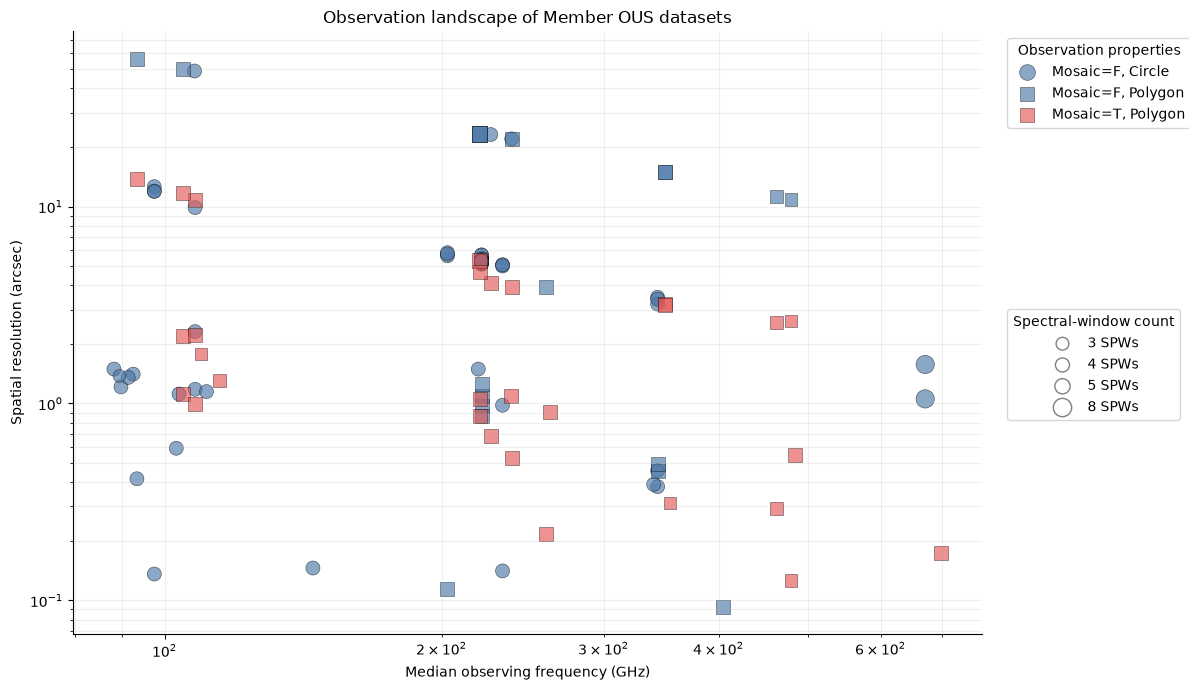

In [74]:
import numpy as np
import matplotlib.pyplot as plt

member_visual_df = (
    full_coordinate_df
    .groupby("member_ous_uid", dropna=False)
    .agg(
        proposal_id=("proposal_id", "first"),
        target_name=("target_name", "first"),
        median_frequency_ghz=("frequency", "median"),
        spatial_resolution_arcsec=(
            "spatial_resolution",
            "first",
        ),
        spw_count=("obs_id", "nunique"),
        mosaic_state=("is_mosaic", "first"),
        geometry_type=("region_geometry_type", "first"),
    )
    .reset_index()
)

member_visual_df = member_visual_df.loc[
    member_visual_df["median_frequency_ghz"].notna()
    & member_visual_df["spatial_resolution_arcsec"].notna()
    & (member_visual_df["median_frequency_ghz"] > 0)
    & (member_visual_df["spatial_resolution_arcsec"] > 0)
].copy()

colour_map = {
    "F": "#4C78A8",
    "T": "#E45756",
}

marker_map = {
    "Circle": "o",
    "Polygon": "s",
}

fig, ax = plt.subplots(figsize=(12, 7))

for (mosaic, geometry), group in member_visual_df.groupby(
    ["mosaic_state", "geometry_type"]
):
    ax.scatter(
        group["median_frequency_ghz"],
        group["spatial_resolution_arcsec"],
        s=30 + group["spw_count"] * 18,
        color=colour_map.get(str(mosaic), "gray"),
        marker=marker_map.get(str(geometry), "o"),
        alpha=0.65,
        edgecolor="black",
        linewidth=0.4,
        label=f"Mosaic={mosaic}, {geometry}",
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title(
    "Observation landscape of Member OUS datasets"
)
ax.set_xlabel("Median observing frequency (GHz)")
ax.set_ylabel("Spatial resolution (arcsec)")


observation_legend = ax.legend(
    title="Observation properties",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
)


ax.add_artist(observation_legend)


size_handles = [
    ax.scatter(
        [],
        [],
        s=30 + spw_count * 18,
        facecolor="none",
        edgecolor="gray",
        linewidth=1,
        marker="o",
        label=f"{spw_count} SPWs",
    )
    for spw_count in [3, 4, 5, 8]
]

ax.legend(
    handles=size_handles,
    title="Spectral-window count",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.55),
)

ax.grid(alpha=0.2, which="both")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Distribution of spectral-window counts

This figure shows that the number of spectral-window-related Archive rows is
not fixed across Member OUS datasets.

Matplotlib is building the font cache; this may take a moment.


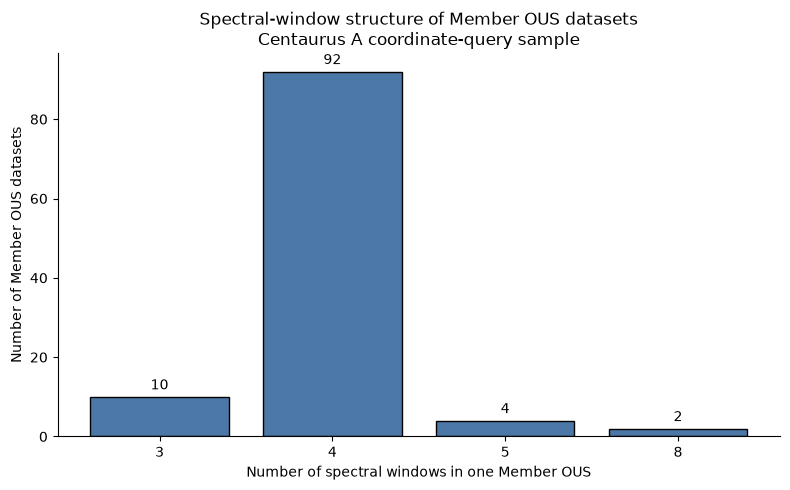

In [63]:
import matplotlib.pyplot as plt

spw_count_distribution = (
    frequency_structure_summary[
        "spw_identifier_count"
    ]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    spw_count_distribution.index.astype(str),
    spw_count_distribution.values,
    color="#4C78A8",
    edgecolor="black",
)

ax.bar_label(bars, padding=3)

ax.set_title(
    "Spectral-window structure of Member OUS datasets\n"
    "Centaurus A coordinate-query sample"
)
ax.set_xlabel(
    "Number of spectral windows in one Member OUS"
)
ax.set_ylabel("Number of Member OUS datasets")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Comparison of two bandwidth representations

The dashed diagonal represents exact agreement between the Archive
`bandwidth` column and the width derived from the matched
`frequency_support` interval.

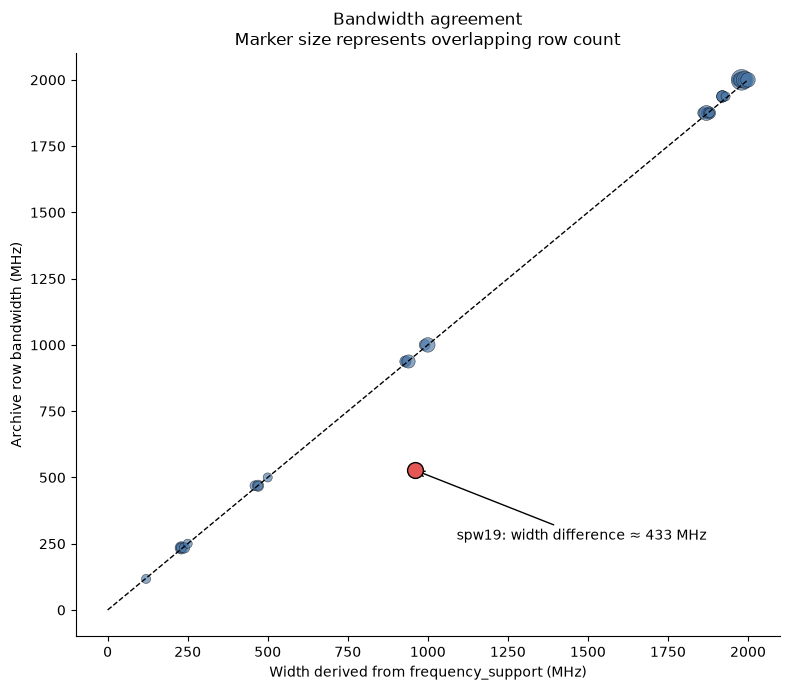

In [68]:
bandwidth_count_df = (
    bandwidth_plot_df
    .groupby(
        [
            "support_width_mhz",
            "archive_bandwidth_mhz",
        ],
        as_index=False,
    )
    .size()
)

normal_count_df = bandwidth_count_df.loc[
    (
        bandwidth_count_df[
            "support_width_mhz"
        ]
        - bandwidth_count_df[
            "archive_bandwidth_mhz"
        ]
    ).abs() <= 100
]

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    normal_count_df["support_width_mhz"],
    normal_count_df["archive_bandwidth_mhz"],
    s=25 + 18 * np.sqrt(normal_count_df["size"]),
    color="#4C78A8",
    alpha=0.65,
    edgecolor="black",
    linewidth=0.4,
)

maximum_width = max(
    bandwidth_plot_df["support_width_mhz"].max(),
    bandwidth_plot_df["archive_bandwidth_mhz"].max(),
)

ax.plot(
    [0, maximum_width],
    [0, maximum_width],
    linestyle="--",
    color="black",
    linewidth=1,
)

ax.scatter(
    outlier["support_width_mhz"],
    outlier["archive_bandwidth_mhz"],
    s=130,
    color="#E45756",
    edgecolor="black",
    zorder=5,
)

ax.annotate(
    "spw19: width difference ≈ 433 MHz",
    xy=(
        outlier["support_width_mhz"],
        outlier["archive_bandwidth_mhz"],
    ),
    xytext=(30, -50),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
)

ax.set_title(
    "Bandwidth agreement\n"
    "Marker size represents overlapping row count"
)
ax.set_xlabel(
    "Width derived from frequency_support (MHz)"
)
ax.set_ylabel("Archive row bandwidth (MHz)")

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Spectral-coverage atlas

Each horizontal segment represents the frequency range of one Archive
source–spectral-window-related record. Member OUS datasets are ordered by
their median observing frequency.

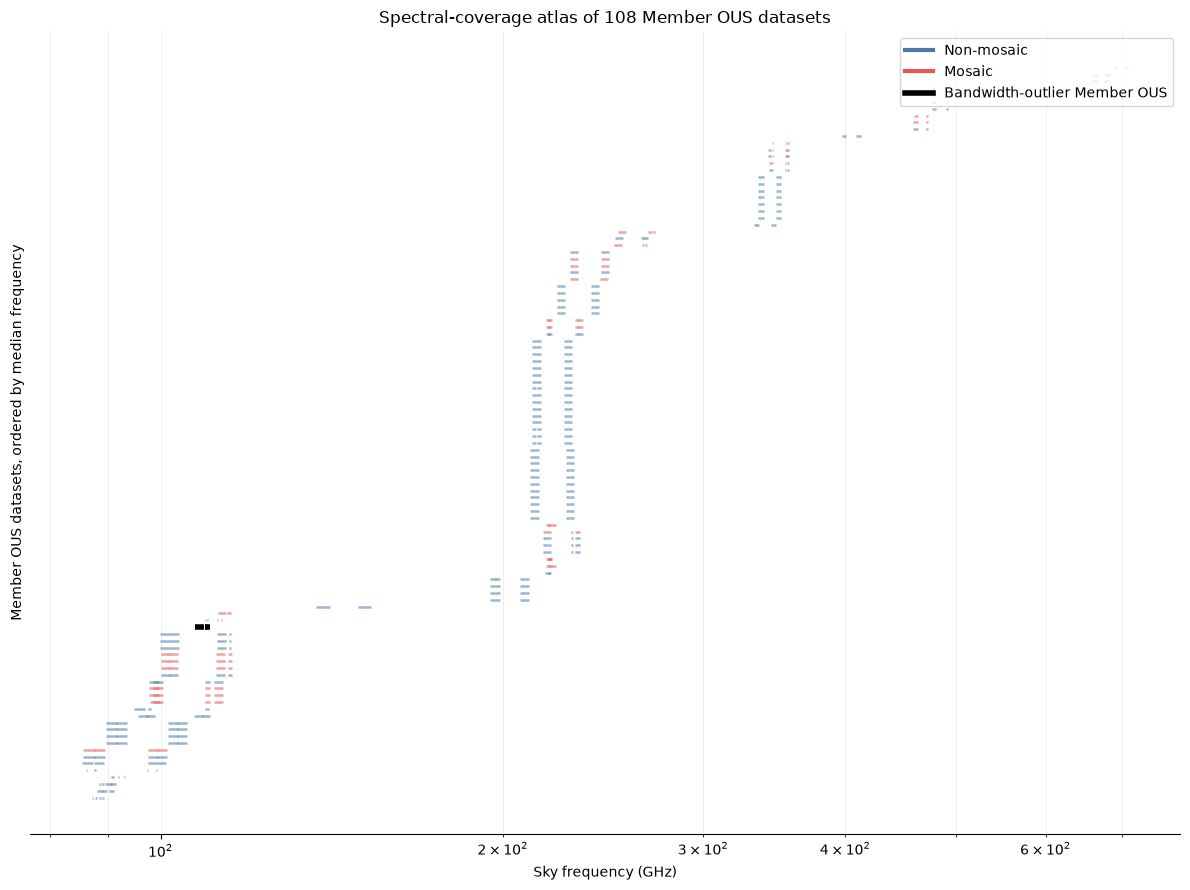

In [67]:
from matplotlib.lines import Line2D

atlas_df = (
    row_frequency_bounds_df
    .merge(
        full_coordinate_df[
            ["member_ous_uid", "is_mosaic"]
        ].drop_duplicates(),
        on="member_ous_uid",
        how="left",
    )
)

member_order = (
    atlas_df
    .groupby("member_ous_uid")["frequency"]
    .median()
    .sort_values()
    .index
)

member_position = {
    member_uid: position
    for position, member_uid in enumerate(member_order)
}

atlas_df["member_position"] = (
    atlas_df["member_ous_uid"]
    .map(member_position)
)

fig, ax = plt.subplots(figsize=(12, 9))

non_outlier_df = atlas_df.loc[
    atlas_df["member_ous_uid"]
    != frequency_outlier_member
]

for mosaic_state, group in non_outlier_df.groupby(
    "is_mosaic"
):
    colour = (
        "#E45756"
        if str(mosaic_state) == "T"
        else "#4C78A8"
    )

    ax.hlines(
        y=group["member_position"],
        xmin=group["row_lower_ghz"],
        xmax=group["row_upper_ghz"],
        color=colour,
        alpha=0.55,
        linewidth=1.8,
    )

outlier_atlas_df = atlas_df.loc[
    atlas_df["member_ous_uid"]
    == frequency_outlier_member
]

ax.hlines(
    y=outlier_atlas_df["member_position"],
    xmin=outlier_atlas_df["row_lower_ghz"],
    xmax=outlier_atlas_df["row_upper_ghz"],
    color="black",
    linewidth=4,
    zorder=5,
)

ax.set_xscale("log")

ax.set_title(
    "Spectral-coverage atlas of 108 Member OUS datasets"
)
ax.set_xlabel("Sky frequency (GHz)")
ax.set_ylabel(
    "Member OUS datasets, ordered by median frequency"
)

ax.set_yticks([])

legend_elements = [
    Line2D(
        [0],
        [0],
        color="#4C78A8",
        linewidth=3,
        label="Non-mosaic",
    ),
    Line2D(
        [0],
        [0],
        color="#E45756",
        linewidth=3,
        label="Mosaic",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=4,
        label="Bandwidth-outlier Member OUS",
    ),
]

ax.legend(handles=legend_elements)
ax.grid(axis="x", alpha=0.2, which="both")
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

## Final Conclusions from the Centaurus A Archive Case Study

The complete coordinate query returned 434 Archive rows belonging to 108
Member OUS datasets. Within this sample, `member_ous_uid` provides a strong
preliminary grouping key: the project identifiers, target metadata, reference
coordinates, spatial footprint, spatial resolution, antenna-array description,
mosaic status, continuum sensitivity, and complete `frequency_support`
description were internally consistent within every Member OUS.

All 434 `obs_id` values could be parsed into source and spectral-window
components. Each Member OUS contained one source and a variable number of
spectral-window identifiers: three, four, five, or eight. The Archive-row
count, spectral-window identifier count, and parsed `frequency_support`
interval count agreed for all 108 Member OUS groups.

The repeated `frequency_support` value appears to describe the complete
spectral setup of a Member OUS, while individual Archive rows contain
structured metadata for one source–spectral-window-related component.

Matching rows to support intervals by central frequency alone was unreliable
because some spectral windows had nearly identical central frequencies but
different bandwidths. A one-to-one assignment based on lower and upper
frequency bounds substantially reduced the matching errors. After one-to-one assignment, 433 of the 434 Archive rows had a bandwidth difference of no more than 30 MHz relative to the matched
`frequency_support` interval. The remaining row had a substantially larger
difference of approximately 433 MHz.

One row retained a substantially larger width discrepancy: its Archive
`bandwidth` was approximately 0.527 GHz, while the matched support interval
covered approximately 0.960 GHz. Therefore, the Archive `bandwidth` column and
the width derived from `frequency_support` must be preserved as separate
representations until their exact semantics have been confirmed.

The spatial experiment showed that footprint intersection cannot be replaced
by reference-centre distance. One mosaic Member OUS was retrieved through its
`s_region` footprint even though its reference centre lay outside the search
radius. Mosaic classification and footprint geometry must also remain separate,
because polygon footprints occurred in both mosaic and non-mosaic datasets.

These conclusions are strongly supported within the Centaurus A sample, but
they must be tested against additional targets, observing modes, frequency
bands, and Archive cycles before being treated as Archive-wide constraints.

Inspection of the remaining outlier confirmed that the interval assignment
was not ambiguous: the Archive-row centre frequency and the
`frequency_support` interval centre were closely aligned. However, the Archive
`bandwidth` was approximately 0.527 GHz, while the support interval covered
approximately 0.960 GHz. The same Member OUS contained two other spectral
windows whose row bandwidths and support widths agreed closely.

This case indicates that the Archive `bandwidth` column and the width derived
from `frequency_support` cannot yet be treated as interchangeable
representations. Both values must be preserved until their exact semantics and
the cause of such discrepancies have been confirmed.